In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, GlobalMaxPooling2D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.applications import MobileNetV2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file = '/content/drive/MyDrive/vitamin_def.zip'

In [ ]:
import zipfile as zf
data_zip = zf.ZipFile(file)
data_zip.extractall()
!ls

dataset  drive	sample_data


In [ ]:
data=r'/content/dataset'

In [ ]:
images=[]
import os
for dirname,_,filenames in os.walk(data):
  for filename in filenames:
    file_name, file_extension = os.path.splitext(filename)
    if file_extension == '.db':
      continue
    else:
      img=os.path.join(dirname,filename)
      images.append(img)

In [ ]:
images[:20]

['/content/dataset/Vitamin K deficiency/hemangioma-infancy-32 - Copy - Copy.jpg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (89).jpeg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (135) - Copy.jpeg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (216) - Copy.jpeg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (202) - Copy.jpeg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (160).jpeg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (185) - Copy.jpeg',
 '/content/dataset/Vitamin K deficiency/hemangioma-infancy-55 - Copy.jpg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (200) - Copy.jpeg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (283) - Copy.jpeg',
 '/content/dataset/Vitamin K deficiency/hemangioma-infancy-40 - Copy - Copy (2).jpg',
 '/content/dataset/Vitamin K deficiency/Blood cloth (176) - Copy.JPEG',
 '/content/dataset/Vitamin K deficiency/hemangioma-infancy-32 - Copy (2).jpg',
 '/content/dataset/Vitamin K deficiency/heman

In [ ]:
len(images)

23207

In [ ]:
class_values = []
for i in images:
    j = i.split('/')
    class_values.append(j[-2])

In [ ]:
class_values[:10]

['Vitamin K deficiency',
 'Vitamin K deficiency',
 'Vitamin K deficiency',
 'Vitamin K deficiency',
 'Vitamin K deficiency',
 'Vitamin K deficiency',
 'Vitamin K deficiency',
 'Vitamin K deficiency',
 'Vitamin K deficiency',
 'Vitamin K deficiency']

In [ ]:
len(class_values)

23207

In [ ]:
import random
temp = list(zip(images,class_values))
random.shuffle(temp)
images, class_values = zip(*temp)
data = pd.DataFrame(list(zip(images, class_values)), columns=['image_path', 'Class_label'])

In [ ]:
data

,image_path,Class_label
0,/content/dataset/Vitamin A deficiency/distal-s...,Vitamin A deficiency
1,/content/dataset/Vitamin B-12 deficiency/Psori...,Vitamin B-12 deficiency
2,/content/dataset/Vitamin A deficiency/images-1...,Vitamin A deficiency
3,/content/dataset/Vitamin A deficiency/Pterygiu...,Vitamin A deficiency
4,/content/dataset/Vitamin A deficiency/Pterygiu...,Vitamin A deficiency
...,...,...
23202,/content/dataset/Vitamin D deficiency/basal-ce...,Vitamin D deficiency
23203,/content/dataset/Vitamin A deficiency/image-6 ...,Vitamin A deficiency
23204,/content/dataset/Vitamin D deficiency/fissure-...,Vitamin D deficiency
23205,/content/dataset/Vitamin D deficiency/actinic-...,Vitamin D deficiency


In [ ]:
data.Class_label.value_counts()

,count
Class_label,
Vitamin D deficiency,9099
Vitamin A deficiency,6499
Vitamin B-12 deficiency,2273
"zinc, iron, biotin, or protein deficiency",750
Vitamin E deficiency,692
Vitamin K deficiency,690
Vitamin C deficiency,664
Vitamin B3 deficiency,660
Vitamin B2 deficiency,656


In [ ]:
from sklearn.utils import resample
df_c0 = data[data['Class_label'] =="Vitamin D deficiency"]
df_c1 = data[data['Class_label'] =="Vitamin A deficiency"]
df_c2 = data[data['Class_label'] =="Vitamin B-12 deficiency"]
df_c3 = data[data['Class_label'] =="zinc, iron, biotin, or protein deficiency"]
df_c4 = data[data['Class_label'] =="Vitamin E deficiency"]
df_c5 = data[data['Class_label'] =="Vitamin K deficiency"]
df_c6 = data[data['Class_label'] =="Vitamin C deficiency"]
df_c7 = data[data['Class_label'] =="Vitamin B3 deficiency"]
df_c8 = data[data['Class_label'] =="Vitamin B2 deficiency"]
df_c9 = data[data['Class_label'] =="Vitamin B1 deficiency"]
df_c10 = data[data['Class_label'] =="Vitamin B9 deficiency"]

unsampled_df_c0 = resample(df_c0, replace=True, random_state=23, n_samples=3000)
unsampled_df_c1 = resample(df_c1, replace=True, random_state=23, n_samples=3000)
unsampled_df_c2 = resample(df_c2, replace=True, random_state=23, n_samples=3000)
unsampled_df_c3 = resample(df_c3, replace=True, random_state=23, n_samples=3000)
unsampled_df_c4 = resample(df_c4, replace=True, random_state=23, n_samples=3000)
unsampled_df_c5 = resample(df_c5, replace=True, random_state=23, n_samples=3000)
unsampled_df_c6 = resample(df_c6, replace=True, random_state=23, n_samples=3000)
unsampled_df_c7 = resample(df_c7, replace=True, random_state=23, n_samples=3000)
unsampled_df_c8 = resample(df_c8, replace=True, random_state=23, n_samples=3000)
unsampled_df_c9 = resample(df_c9, replace=True, random_state=23, n_samples=3000)
unsampled_df_c10 = resample(df_c10, replace=True, random_state=23, n_samples=3000)


df_unsampled = pd.concat([unsampled_df_c0, unsampled_df_c1, unsampled_df_c2, unsampled_df_c3, unsampled_df_c4, unsampled_df_c5, unsampled_df_c6, unsampled_df_c7, unsampled_df_c8, unsampled_df_c9, unsampled_df_c10])
df_unsampled

,image_path,Class_label
22443,/content/dataset/Vitamin D deficiency/05atopic...,Vitamin D deficiency
15826,/content/dataset/Vitamin D deficiency/lichen-p...,Vitamin D deficiency
975,/content/dataset/Vitamin D deficiency/squamous...,Vitamin D deficiency
111,/content/dataset/Vitamin D deficiency/actinic-...,Vitamin D deficiency
9521,/content/dataset/Vitamin D deficiency/enterovi...,Vitamin D deficiency
...,...,...
2427,/content/dataset/Vitamin B9 deficiency/folate ...,Vitamin B9 deficiency
2378,/content/dataset/Vitamin B9 deficiency/folate ...,Vitamin B9 deficiency
17965,/content/dataset/Vitamin B9 deficiency/folate ...,Vitamin B9 deficiency
19387,/content/dataset/Vitamin B9 deficiency/folate ...,Vitamin B9 deficiency


In [ ]:
df = df_unsampled
df.head()

,image_path,Class_label
22443,/content/dataset/Vitamin D deficiency/05atopic...,Vitamin D deficiency
15826,/content/dataset/Vitamin D deficiency/lichen-p...,Vitamin D deficiency
975,/content/dataset/Vitamin D deficiency/squamous...,Vitamin D deficiency
111,/content/dataset/Vitamin D deficiency/actinic-...,Vitamin D deficiency
9521,/content/dataset/Vitamin D deficiency/enterovi...,Vitamin D deficiency


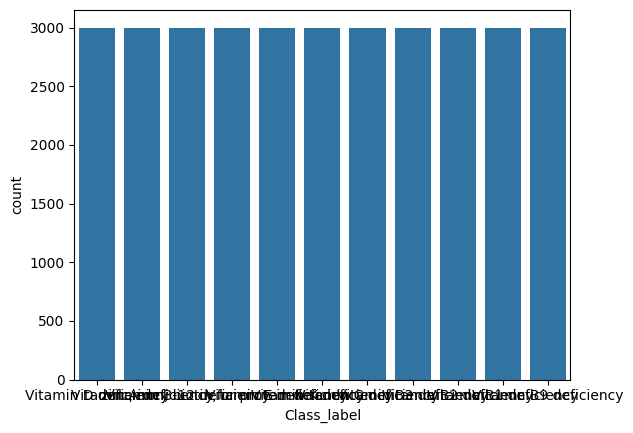

In [ ]:
sns.countplot(x = df.Class_label, data = df)
plt.show()

In [ ]:
df

,image_path,Class_label
22443,/content/dataset/Vitamin D deficiency/05atopic...,Vitamin D deficiency
15826,/content/dataset/Vitamin D deficiency/lichen-p...,Vitamin D deficiency
975,/content/dataset/Vitamin D deficiency/squamous...,Vitamin D deficiency
111,/content/dataset/Vitamin D deficiency/actinic-...,Vitamin D deficiency
9521,/content/dataset/Vitamin D deficiency/enterovi...,Vitamin D deficiency
...,...,...
2427,/content/dataset/Vitamin B9 deficiency/folate ...,Vitamin B9 deficiency
2378,/content/dataset/Vitamin B9 deficiency/folate ...,Vitamin B9 deficiency
17965,/content/dataset/Vitamin B9 deficiency/folate ...,Vitamin B9 deficiency
19387,/content/dataset/Vitamin B9 deficiency/folate ...,Vitamin B9 deficiency


In [ ]:
df['image_path'].value_counts()

,count
image_path,
/content/dataset/Vitamin B2 deficiency/glossitis (58).jpeg,14
/content/dataset/Vitamin B9 deficiency/folate defficient (160) - Copy.jpeg,14
/content/dataset/Vitamin K deficiency/Blood cloth (88).jpeg,14
/content/dataset/Vitamin B1 deficiency/beriberi (232).jpeg,14
/content/dataset/Vitamin E deficiency/E Defficient (267) - Copy.jpeg,14
...,...
/content/dataset/Vitamin B9 deficiency/folate defficient (426) - Copy.jpeg,1
/content/dataset/Vitamin B9 deficiency/folate defficient (48) - Copy.jpg,1
/content/dataset/Vitamin B9 deficiency/folate defficient (24) - Copy.jpg,1


In [ ]:
from PIL import Image
def resize_images(img):
  file = Image.open(img)
  img = file.convert('RGB')
  img_bgr= img.resize((124, 124))
  img_bgr = np.array(img_bgr)
  return img_bgr

In [ ]:
#save resized images into images.
images = [resize_images(img) for img in df['image_path']]

In [ ]:
# print number of classes in our dataset
num_classes = len(np.unique(data['Class_label']))

In [ ]:
num_classes

11

In [ ]:
# save the class into class_names
class_names = list(data['Class_label'])

In [ ]:
# Print the shape of the image
images[0].shape

(124, 124, 3)

Text(0.5, 1.0, 'Vitamin D deficiency')

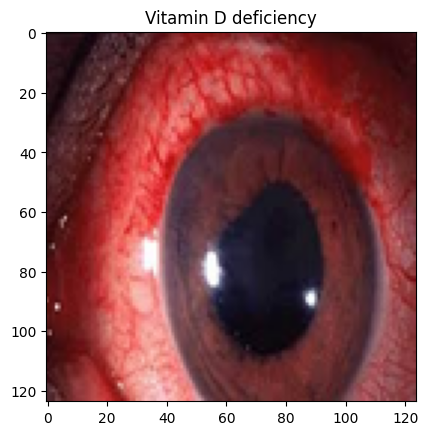

In [ ]:
#See the image with class label
plt.imshow(images[250])
plt.title(class_names[250])

In [ ]:
# Convert the images into array
images =  np.array(images)

In [ ]:
# Shape of the images
images.shape

(33000, 124, 124, 3)

In [ ]:
from sklearn.preprocessing import LabelEncoder
enc=LabelEncoder()
Y = enc.fit_transform(df['Class_label'])
from keras.utils  import to_categorical
y1 = to_categorical(Y)

In [ ]:
enc.classes_

array(['Vitamin A deficiency', 'Vitamin B-12 deficiency',
       'Vitamin B1 deficiency', 'Vitamin B2 deficiency',
       'Vitamin B3 deficiency', 'Vitamin B9 deficiency',
       'Vitamin C deficiency', 'Vitamin D deficiency',
       'Vitamin E deficiency', 'Vitamin K deficiency',
       'zinc, iron, biotin, or protein deficiency'], dtype=object)

In [ ]:
y1.shape

(33000, 11)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, y1, test_size=0.3,stratify = y1,random_state=42)

In [ ]:
# Importing necessary libraries
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Loading data
train_generator = train_datagen.flow(
    X_train, y_train, batch_size=32, shuffle=True
)
valid_generator = test_datagen.flow(
    X_test, y_test, batch_size=32, shuffle=False
)

# Compute class weights to handle imbalance
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    "balanced", classes=np.unique(y_train_classes), y=y_train_classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights: ", class_weights)

# Loading the MobileNet model
mobilenet_base = MobileNet(
    weights="imagenet", include_top=False, input_shape=(124, 124, 3)
)

# Adding custom layers
x = mobilenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions = Dense(11, activation="softmax")(x)  # 2 classes

model = Model(inputs=mobilenet_base.input, outputs=predictions)

# Freeze base model layers to train only the custom layers initially
for layer in mobilenet_base.layers:
    layer.trainable = False

# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=4, min_lr=1e-6
)

# Fine-tuning: Unfreeze all layers and retrain
for layer in mobilenet_base.layers:
    layer.trainable = True

# Re-compile the model with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
)


Class Weights:  {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0)}


<ipython-input-34-48a420cde97f>:42: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNet(


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 147s 163ms/step - accuracy: 0.2995 - loss: 2.5498 - val_accuracy: 0.7770 - val_loss: 0.7282 - learning_rate: 1.0000e-05
Epoch 2/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 103s 143ms/step - accuracy: 0.6892 - loss: 0.9819 - val_accuracy: 0.8152 - val_loss: 0.5075 - learning_rate: 1.0000e-05
Epoch 3/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 105s 146ms/step - accuracy: 0.7690 - loss: 0.6826 - val_accuracy: 0.8495 - val_loss: 0.4194 - learning_rate: 1.0000e-05
Epoch 4/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 102s 142ms/step - accuracy: 0.8063 - loss: 0.5592 - val_accuracy: 0.8642 - val_loss: 0.3664 - learning_rate: 1.0000e-05
Epoch 5/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 102s 141ms/step - accuracy: 0.8215 - loss: 0.4974 - val_accuracy: 0.8719 - val_loss: 0.3348 - learning_rate: 1.0000e-05
Epoch 6/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 103s 143ms/step - accuracy: 0.8396 - loss: 0.4481 - val_accuracy: 0.8797 - val_loss: 0.3122 - learning_rate: 1.0000e-05
Epoch 7/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Save the trained model
model.save("model.h5")

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(valid_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8885 - loss: 0.2737
Validation Accuracy: 89.38%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict on the validation data
y_pred = model.predict(valid_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class labels

# Access true labels from y_test
y_true_classes = np.argmax(y_test, axis=1)  # True class labels

# Print classification report
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=enc.classes_))  # Use enc.classes_ for class names

310/310 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step
Classification Report:
                                           precision    recall  f1-score   support

                     Vitamin A deficiency       0.80      0.69      0.74       900
                  Vitamin B-12 deficiency       0.61      0.69      0.65       900
                    Vitamin B1 deficiency       0.95      0.97      0.96       900
                    Vitamin B2 deficiency       1.00      1.00      1.00       900
                    Vitamin B3 deficiency       1.00      1.00      1.00       900
                    Vitamin B9 deficiency       1.00      1.00      1.00       900
                     Vitamin C deficiency       0.99      1.00      0.99       900
                     Vitamin D deficiency       0.63      0.55      0.59       900
                     Vitamin E deficiency       0.96      0.95      0.96       900
                     Vitamin K deficiency       0.98      1.00      0.99       900
zinc, iron, biotin, o

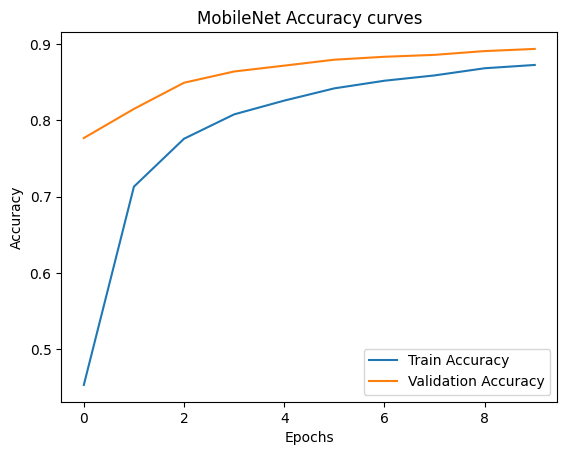

In [ ]:
# Plot training and validation accuracy
plt.plot(history_fine.history["accuracy"], label="Train Accuracy")
plt.plot(history_fine.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNet Accuracy curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

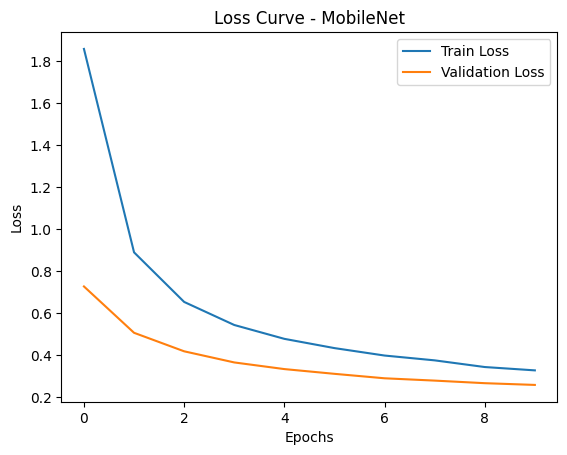

In [ ]:
# Loss Plot
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve - MobileNet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


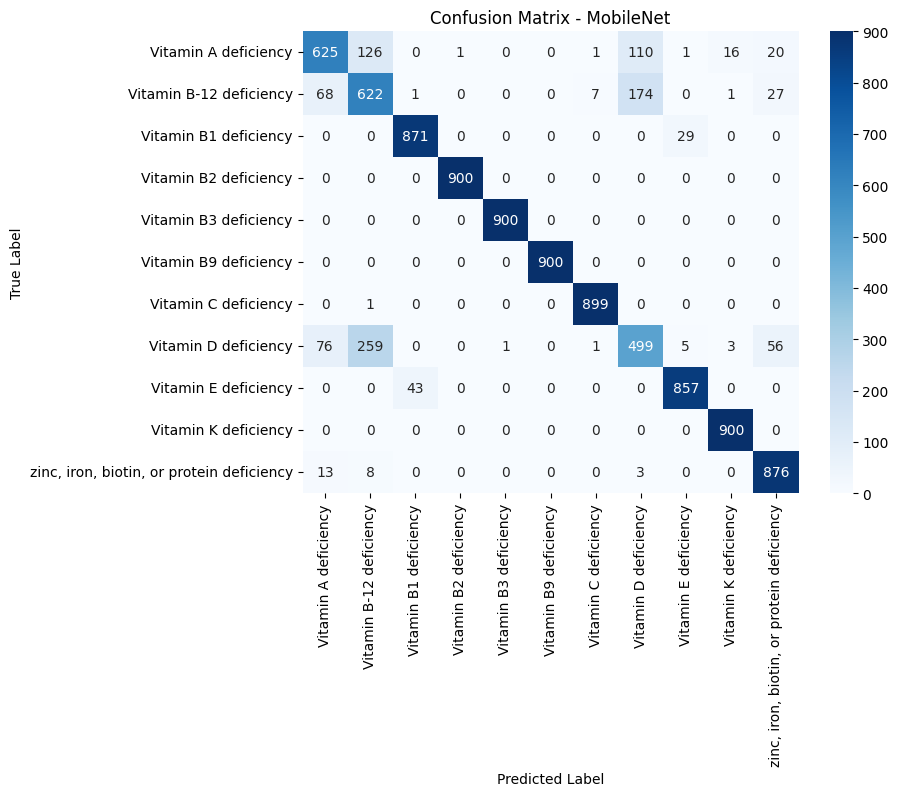

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on the validation data
y_pred = model.predict(valid_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class labels

# Access true labels from y_test
y_true_classes = np.argmax(y_test, axis=1)  # True class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=enc.classes_,  # Use enc.classes_ for class names
    yticklabels=enc.classes_,  # Use enc.classes_ for class names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MobileNet")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: Vitamin A deficiency
Actual class: Vitamin A deficiency


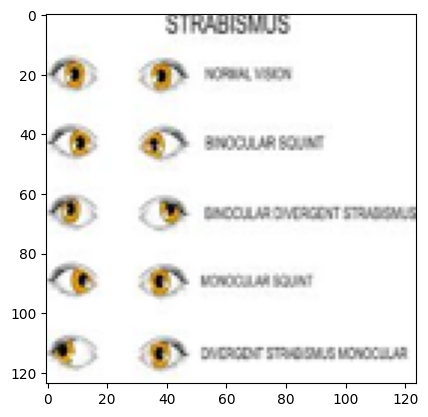

In [ ]:
i = 56
pred = np.argmax(model.predict(np.array([X_test[i]]))[0])
act = np.argmax(y_test[i])
print("Predicted class: {}".format(enc.classes_[pred]))
print("Actual class: {}".format(enc.classes_[act]))
plt.imshow(X_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted class: Vitamin A deficiency
Actual class: Vitamin A deficiency


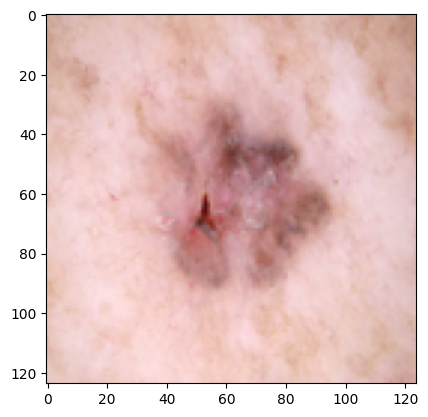

In [ ]:
i = 22
pred = np.argmax(model.predict(np.array([X_test[i]]))[0])
act = np.argmax(y_test[i])
print("Predicted class: {}".format(enc.classes_[pred]))
print("Actual class: {}".format(enc.classes_[act]))
plt.imshow(X_test[i])

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Loading data
train_generator = train_datagen.flow(
    X_train, y_train, batch_size=32, shuffle=True
)
valid_generator = test_datagen.flow(
    X_test, y_test, batch_size=32, shuffle=False
)

# Compute class weights to handle imbalance
y_train_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    "balanced", classes=np.unique(y_train_classes), y=y_train_classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights: ", class_weights)

# Loading the VGG16 model
vgg_base = VGG16(
    weights="imagenet", include_top=False, input_shape=(124, 124, 3)
)

# Adding custom layers
x = vgg_base.output
x = Flatten()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.2)(x)
predictions = Dense(11, activation="softmax")(x)  # 11 classes

model = Model(inputs=vgg_base.input, outputs=predictions)

# Freeze base model layers to train only the custom layers initially
for layer in vgg_base.layers:
    layer.trainable = False

# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=4, min_lr=1e-6
)

# Fine-tuning: Unfreeze all layers and retrain
for layer in vgg_base.layers:
    layer.trainable = True

# Re-compile the model with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
)


Class Weights:  {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0)}
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 200s 248ms/step - accuracy: 0.4927 - loss: 1.4799 - val_accuracy: 0.8429 - val_loss: 0.4117 - learning_rate: 1.0000e-05
Epoch 2/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 160s 213ms/step - accuracy: 0.8190 - loss: 0.4860 - val_accuracy: 0.8653 - val_loss: 0.3291 - learning_rate: 1.0000e-05
Epoch 3/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 155s 215ms/step - accuracy: 0.8492 - loss: 0.3852 - val_accuracy: 0.8663 - val_loss: 0.3158 - learning_rate: 1.0000e-05
Epoch 4/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 153s 211ms/step - accuracy: 0.8655 - loss: 0.3280 - val_accuracy: 0.8866 - val_loss: 0.2832 - learning_rate: 1.0000e-05
Epoch 5/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 154s 213ms/step - accuracy: 0.8800 - loss: 0.2962 - val_accuracy: 0.8900 - val_loss: 0.2706 - learning_rate: 1.0000e-05
Epoch 6/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 154s 213ms/step - accuracy: 0.8880 - loss: 0.2735 - val_accuracy: 0.8881 - val_loss: 0.2705 - learning_rate: 1.0000e-05
Epoch 7/20
722/722 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Save the trained model
model.save("vgg.h5")

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(valid_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

310/310 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9062 - loss: 0.2297
Validation Accuracy: 91.02%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict on the validation data
y_pred = model.predict(valid_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class labels

# Access true labels from y_test
y_true_classes = np.argmax(y_test, axis=1)  # True class labels

# Print classification report
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=enc.classes_))  # Use enc.classes_ for class names

310/310 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step
Classification Report:
                                           precision    recall  f1-score   support

                     Vitamin A deficiency       0.79      0.75      0.77       900
                  Vitamin B-12 deficiency       0.67      0.83      0.74       900
                    Vitamin B1 deficiency       0.94      0.96      0.95       900
                    Vitamin B2 deficiency       1.00      1.00      1.00       900
                    Vitamin B3 deficiency       1.00      1.00      1.00       900
                    Vitamin B9 deficiency       1.00      1.00      1.00       900
                     Vitamin C deficiency       0.99      1.00      1.00       900
                     Vitamin D deficiency       0.73      0.57      0.64       900
                     Vitamin E deficiency       0.96      0.94      0.95       900
                     Vitamin K deficiency       1.00      1.00      1.00       900
zinc, iron, biotin, 

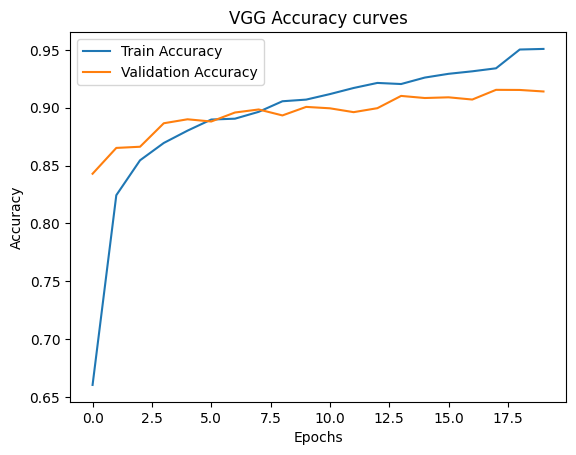

In [ ]:
# Plot training and validation accuracy
plt.plot(history_fine.history["accuracy"], label="Train Accuracy")
plt.plot(history_fine.history["val_accuracy"], label="Validation Accuracy")
plt.title("VGG Accuracy curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

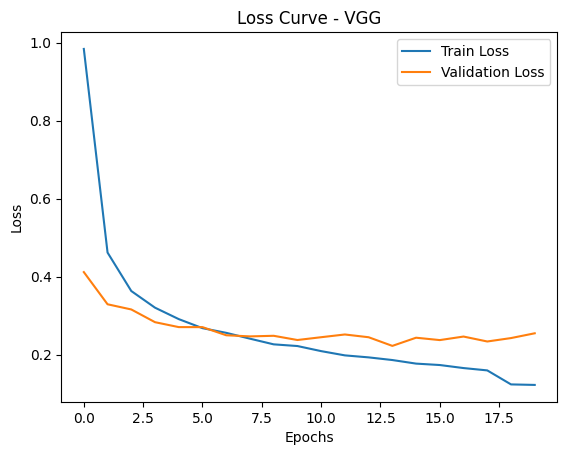

In [ ]:
# Loss Plot
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve - VGG')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

310/310 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step


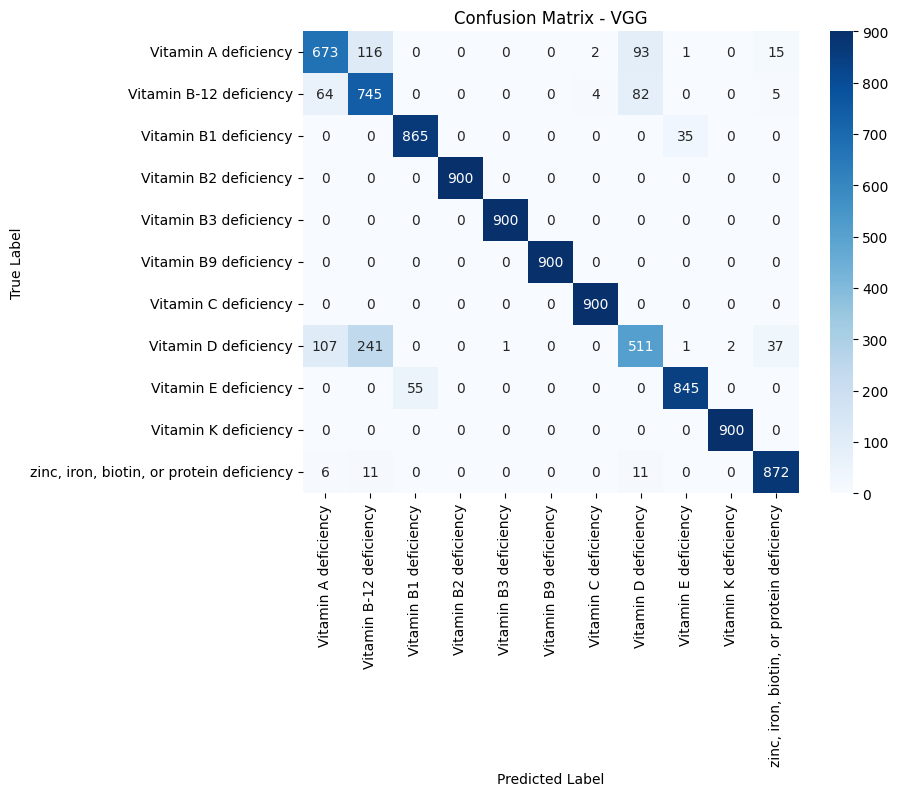

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on the validation data
y_pred = model.predict(valid_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class labels

# Access true labels from y_test
y_true_classes = np.argmax(y_test, axis=1)  # True class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=enc.classes_,  # Use enc.classes_ for class names
    yticklabels=enc.classes_,  # Use enc.classes_ for class names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - VGG")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class: Vitamin A deficiency
Actual class: Vitamin K deficiency


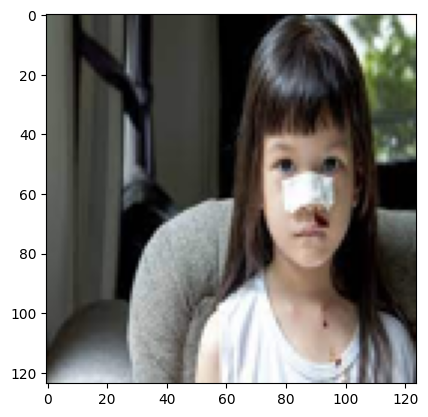

In [ ]:
i = 5
pred = np.argmax(model.predict(np.array([X_test[i]]))[0])
act = np.argmax(y_test[i])
print("Predicted class: {}".format(enc.classes_[pred]))
print("Actual class: {}".format(enc.classes_[act]))
plt.imshow(X_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted class: zinc, iron, biotin, or protein deficiency
Actual class: zinc, iron, biotin, or protein deficiency


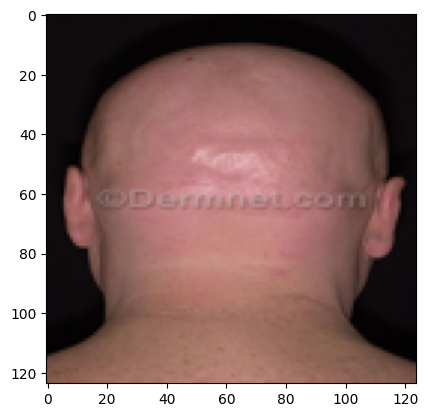

In [ ]:
i = 125
pred = np.argmax(model.predict(np.array([X_test[i]]))[0])
act = np.argmax(y_test[i])
print("Predicted class: {}".format(enc.classes_[pred]))
print("Actual class: {}".format(enc.classes_[act]))
plt.imshow(X_test[i])